# Medical Datasets — Load & Summary

Loads all 8 medical datasets used in the XAI benchmarking study (reproducing Kruschel et al. 2026).

| # | Dataset | Task | Instances | Loader |
|---|---|---|---|---|
| 1 | Diabetes 130-US Hospitals | Classification | ~101,766 | ucimlrepo |
| 2 | Thyroid Disease | Classification | ~2,800 | Direct URL |
| 3 | Wisconsin Breast Cancer | Classification | 569 | ucimlrepo |
| 4 | Heart Failure Clinical Records | Classification | 299 | ucimlrepo |
| 5 | Pima Indians Diabetes | Classification | 768 | Direct URL |
| 6 | Diabetes Progression (Efron 2004) | Regression | 442 | scikit-learn |
| 7 | Chronic Kidney Disease | Regression | 400 | ucimlrepo |
| 8 | Parkinsons Telemonitoring | Regression | 5,875 | ucimlrepo |

**Run `Cell > Run All`.** All downloads are automatic.

In [1]:
# pip install ucimlrepo scikit-learn pandas numpy matplotlib

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes

try:
    from ucimlrepo import fetch_ucirepo
except ImportError:
    raise ImportError("Install with: pip install ucimlrepo")

print("Dependencies OK")

Dependencies OK


In [2]:
# ── Summary helper ────────────────────────────────────────────────────────────

def summarise(name, X, y, task):
    n, p = X.shape
    missing_pct = X.isnull().mean().mean() * 100

    print(f"\n{'='*60}")
    print(f"  {name}")
    print(f"{'='*60}")
    print(f"  Task            : {task}")
    print(f"  Instances       : {n:,}")
    print(f"  Features        : {p}")
    print(f"  Missing (avg)   : {missing_pct:.1f}%")

    if task == 'classification':
        vc = y.value_counts(normalize=True).sort_index()
        for cls, pct in vc.items():
            label = 'positive' if cls == 1 else 'negative'
            print(f"  Class {cls} ({label:<8}): {pct*100:.1f}%")
        print(f"  Imbalance ratio : {vc.max()/vc.min():.1f}:1")
    else:
        print(f"  Target mean     : {y.mean():.3f}")
        print(f"  Target std      : {y.std():.3f}")
        print(f"  Target range    : [{y.min():.3f}, {y.max():.3f}]")

    feat_missing = X.isnull().mean()
    feat_missing = feat_missing[feat_missing > 0].sort_values(ascending=False)
    if len(feat_missing) > 0:
        print(f"  Top missing features:")
        for feat, pct in feat_missing.head(5).items():
            print(f"    {str(feat):<35} {pct*100:.1f}%")

    return {"name": name, "task": task, "n": n, "p": p,
            "missing_pct": round(missing_pct, 1)}


registry = []

---
## 1 — Diabetes 130-US Hospitals (UCI 296)
Target: readmitted within 30 days (1) vs. not (0)

In [3]:
ds = fetch_ucirepo(id=296)
X1 = ds.data.features.copy()
y1_raw = ds.data.targets.copy()

# Binarise: '<30' -> 1, else -> 0
y1 = (y1_raw.iloc[:, 0] == '<30').astype(int)

# Drop high-missingness columns (weight >97%) and ID columns
drop_cols = [c for c in X1.columns
             if c in ('weight', 'encounter_id', 'patient_nbr')
             or X1[c].isnull().mean() > 0.5]
X1 = X1.drop(columns=drop_cols)

registry.append(summarise("Diabetes 130-US Hospitals", X1, y1, 'classification'))


  Diabetes 130-US Hospitals
  Task            : classification
  Instances       : 101,766
  Features        : 44
  Missing (avg)   : 2.1%
  Class 0 (negative): 88.8%
  Class 1 (positive): 11.2%
  Imbalance ratio : 8.0:1
  Top missing features:
    medical_specialty                   49.1%
    payer_code                          39.6%
    race                                2.2%
    diag_3                              1.4%
    diag_2                              0.4%


---
## 2 — Thyroid Disease (UCI allhypo.data)
Target: any hypothyroid diagnosis (1) vs. negative (0)

In [4]:
THYROID_URL = ('https://archive.ics.uci.edu/ml/machine-learning-databases/'
               'thyroid-disease/allhypo.data')

THYROID_COLS = [
    'age', 'sex', 'on_thyroxine', 'query_on_thyroxine', 'on_antithyroid_meds',
    'sick', 'pregnant', 'thyroid_surgery', 'I131_treatment', 'query_hypothyroid',
    'query_hyperthyroid', 'lithium', 'goitre', 'tumor', 'hypopituitary', 'psych',
    'TSH_measured', 'TSH', 'T3_measured', 'T3', 'TT4_measured', 'TT4',
    'T4U_measured', 'T4U', 'FTI_measured', 'FTI', 'TBG_measured', 'TBG',
    'referral_source', 'target_raw'
]

df2 = pd.read_csv(THYROID_URL, header=None, names=THYROID_COLS, na_values='?')

# Strip record ID suffix from target (e.g. 'negative.|3733' -> 'negative')
df2['target_raw'] = df2['target_raw'].str.split('|').str[0].str.rstrip('.')
y2 = (df2['target_raw'] != 'negative').astype(int)

feature_cols = [c for c in THYROID_COLS if c != 'target_raw']
X2 = df2[feature_cols].copy()

# Binary/flag columns are t/f strings — encode as 0/1
binary_cols = ['sex', 'on_thyroxine', 'query_on_thyroxine', 'on_antithyroid_meds',
               'sick', 'pregnant', 'thyroid_surgery', 'I131_treatment',
               'query_hypothyroid', 'query_hyperthyroid', 'lithium', 'goitre',
               'tumor', 'hypopituitary', 'psych',
               'TSH_measured', 'T3_measured', 'TT4_measured',
               'T4U_measured', 'FTI_measured', 'TBG_measured']
for col in binary_cols:
    if col in X2.columns:
        X2[col] = X2[col].map({'t': 1, 'f': 0, 'M': 1, 'F': 0}).fillna(np.nan)

# Numeric columns
num_cols = ['age', 'TSH', 'T3', 'TT4', 'T4U', 'FTI', 'TBG']
for col in num_cols:
    if col in X2.columns:
        X2[col] = pd.to_numeric(X2[col], errors='coerce')

registry.append(summarise("Thyroid Disease", X2, y2, 'classification'))


  Thyroid Disease
  Task            : classification
  Instances       : 2,800
  Features        : 29
  Missing (avg)   : 5.6%
  Class 0 (negative): 92.1%
  Class 1 (positive): 7.9%
  Imbalance ratio : 11.7:1
  Top missing features:
    TBG                                 100.0%
    T3                                  20.9%
    T4U                                 10.6%
    FTI                                 10.5%
    TSH                                 10.1%


---
## 3 — Wisconsin Breast Cancer Diagnostic (UCI 17)
Target: malignant (1) vs. benign (0)

In [5]:
ds = fetch_ucirepo(id=17)
X3 = ds.data.features.copy()
y3 = (ds.data.targets.iloc[:, 0] == 'M').astype(int)

registry.append(summarise("Wisconsin Breast Cancer (Diagnostic)", X3, y3, 'classification'))


  Wisconsin Breast Cancer (Diagnostic)
  Task            : classification
  Instances       : 569
  Features        : 30
  Missing (avg)   : 0.0%
  Class 0 (negative): 62.7%
  Class 1 (positive): 37.3%
  Imbalance ratio : 1.7:1


---
## 4 — Heart Failure Clinical Records (UCI 519)
Target: death event (1) vs. survival (0)

In [6]:
ds = fetch_ucirepo(id=519)
X4 = ds.data.features.copy()
y4 = ds.data.targets.iloc[:, 0].astype(int)

registry.append(summarise("Heart Failure Clinical Records", X4, y4, 'classification'))


  Heart Failure Clinical Records
  Task            : classification
  Instances       : 299
  Features        : 12
  Missing (avg)   : 0.0%
  Class 0 (negative): 67.9%
  Class 1 (positive): 32.1%
  Imbalance ratio : 2.1:1


---
## 5 — Pima Indians Diabetes
Target: diabetes diagnosis (1) vs. no diabetes (0)  
Note: zero-values in 5 clinical features are physiologically impossible — treated as missing.

In [7]:
PIMA_URL  = ('https://raw.githubusercontent.com/jbrownlee/Datasets/master/'
             'pima-indians-diabetes.csv')
PIMA_COLS = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
             'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

df5 = pd.read_csv(PIMA_URL, header=None, names=PIMA_COLS)
y5  = df5['Outcome'].astype(int)
X5  = df5.drop(columns='Outcome').copy()

# Replace physiologically impossible zeros with NaN
zero_coded = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
for col in zero_coded:
    X5.loc[X5[col] == 0, col] = np.nan

registry.append(summarise("Pima Indians Diabetes", X5, y5, 'classification'))


  Pima Indians Diabetes
  Task            : classification
  Instances       : 768
  Features        : 8
  Missing (avg)   : 10.6%
  Class 0 (negative): 65.1%
  Class 1 (positive): 34.9%
  Imbalance ratio : 1.9:1
  Top missing features:
    Insulin                             48.7%
    SkinThickness                       29.6%
    BloodPressure                       4.6%
    BMI                                 1.4%
    Glucose                             0.7%


---
## 6 — Diabetes Progression (Efron et al., 2004)
Target: quantitative disease progression score at 1 year (continuous)

In [8]:
raw = load_diabetes(as_frame=True)
X6  = raw.data.copy()
y6  = raw.target.copy()
X6.columns = ['age', 'sex', 'bmi', 'bp', 'tc', 'ldl', 'hdl', 'tch', 'ltg', 'glu']

registry.append(summarise("Diabetes Progression (Efron 2004)", X6, y6, 'regression'))


  Diabetes Progression (Efron 2004)
  Task            : regression
  Instances       : 442
  Features        : 10
  Missing (avg)   : 0.0%
  Target mean     : 152.133
  Target std      : 77.093
  Target range    : [25.000, 346.000]


---
## 7 — Chronic Kidney Disease (UCI 336) — Regression
Target: serum creatinine (continuous), a direct proxy for glomerular filtration rate.

In [9]:
ds = fetch_ucirepo(id=336)
X7_raw = ds.data.features.copy()

# Identify serum creatinine column
sc_candidates = [c for c in X7_raw.columns
                 if 'sc' in c.lower() or 'creatinine' in c.lower()]
if sc_candidates:
    sc_col = sc_candidates[0]
else:
    # Fallback: use the first numeric column
    sc_col = X7_raw.select_dtypes(include='number').columns[0]
    print(f"Note: serum creatinine column not found by name; using '{sc_col}'")

y7 = pd.to_numeric(X7_raw[sc_col], errors='coerce')
X7 = X7_raw.drop(columns=[sc_col])

# Also drop the binary classification label if present
target_like = [c for c in ds.data.targets.columns] if ds.data.targets is not None else []
# Keep X7 as features only

mask = y7.notna()
X7, y7 = X7[mask].reset_index(drop=True), y7[mask].reset_index(drop=True)

registry.append(summarise("Chronic Kidney Disease — serum creatinine", X7, y7, 'regression'))


  Chronic Kidney Disease — serum creatinine
  Task            : regression
  Instances       : 383
  Features        : 23
  Missing (avg)   : 10.2%
  Target mean     : 3.072
  Target std      : 5.741
  Target range    : [0.400, 76.000]
  Top missing features:
    rbc                                 37.9%
    rbcc                                31.3%
    wbcc                                25.6%
    pot                                 19.3%
    sod                                 19.1%


---
## 8 — Parkinsons Telemonitoring (UCI 189)
Target: total UPDRS score (Parkinson's symptom severity, continuous)

In [10]:
ds = fetch_ucirepo(id=189)
X8_raw = ds.data.features.copy()
y8_raw = ds.data.targets.copy()

# Target: total_UPDRS (second column if two target columns exist)
if 'total_UPDRS' in y8_raw.columns:
    y8 = y8_raw['total_UPDRS'].astype(float)
else:
    y8 = y8_raw.iloc[:, -1].astype(float)   # last column

# Drop subject identifier (not predictive)
X8 = X8_raw.drop(columns=[c for c in X8_raw.columns if 'subject' in c.lower()],
                 errors='ignore')

registry.append(summarise("Parkinsons Telemonitoring (total UPDRS)", X8, y8, 'regression'))


  Parkinsons Telemonitoring (total UPDRS)
  Task            : regression
  Instances       : 5,875
  Features        : 19
  Missing (avg)   : 0.0%
  Target mean     : 29.019
  Target std      : 10.700
  Target range    : [7.000, 54.992]


---
## Overview Table

In [11]:
overview = pd.DataFrame(registry)
overview.index = range(1, len(overview) + 1)
overview.index.name = '#'
print(overview.to_string())

                                        name            task       n   p  missing_pct
#                                                                                    
1                  Diabetes 130-US Hospitals  classification  101766  44          2.1
2                            Thyroid Disease  classification    2800  29          5.6
3       Wisconsin Breast Cancer (Diagnostic)  classification     569  30          0.0
4             Heart Failure Clinical Records  classification     299  12          0.0
5                      Pima Indians Diabetes  classification     768   8         10.6
6          Diabetes Progression (Efron 2004)      regression     442  10          0.0
7  Chronic Kidney Disease — serum creatinine      regression     383  23         10.2
8    Parkinsons Telemonitoring (total UPDRS)      regression    5875  19          0.0


---
## Plots

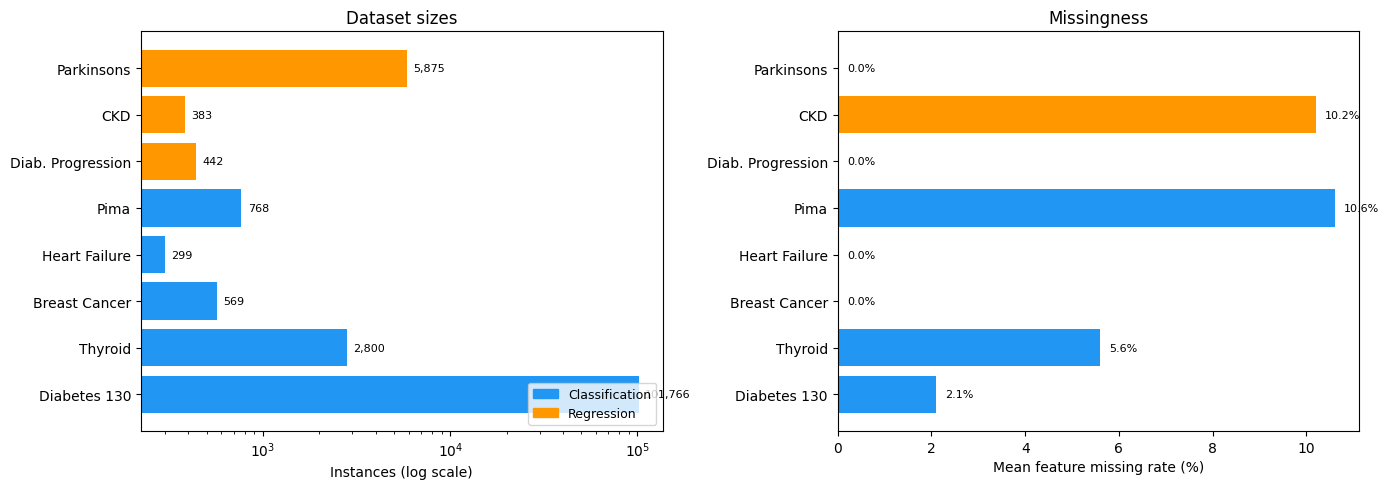

In [12]:
short_names = [
    "Diabetes 130", "Thyroid", "Breast Cancer", "Heart Failure",
    "Pima", "Diab. Progression", "CKD", "Parkinsons"
]
ns      = [r['n'] for r in registry]
missing = [r['missing_pct'] for r in registry]
colors  = ['#2196F3' if r['task'] == 'classification' else '#FF9800'
           for r in registry]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Instance counts (log scale)
axes[0].barh(short_names, ns, color=colors)
axes[0].set_xscale('log')
axes[0].set_xlabel('Instances (log scale)')
axes[0].set_title('Dataset sizes')
for i, v in enumerate(ns):
    axes[0].text(v * 1.08, i, f'{v:,}', va='center', fontsize=8)

# Missingness
axes[1].barh(short_names, missing, color=colors)
axes[1].set_xlabel('Mean feature missing rate (%)')
axes[1].set_title('Missingness')
for i, v in enumerate(missing):
    axes[1].text(v + 0.2, i, f'{v:.1f}%', va='center', fontsize=8)

from matplotlib.patches import Patch
axes[0].legend(
    handles=[Patch(color='#2196F3', label='Classification'),
             Patch(color='#FF9800', label='Regression')],
    loc='lower right', fontsize=9
)

plt.tight_layout()
plt.savefig('medical_datasets_summary.png', dpi=120, bbox_inches='tight')
plt.show()

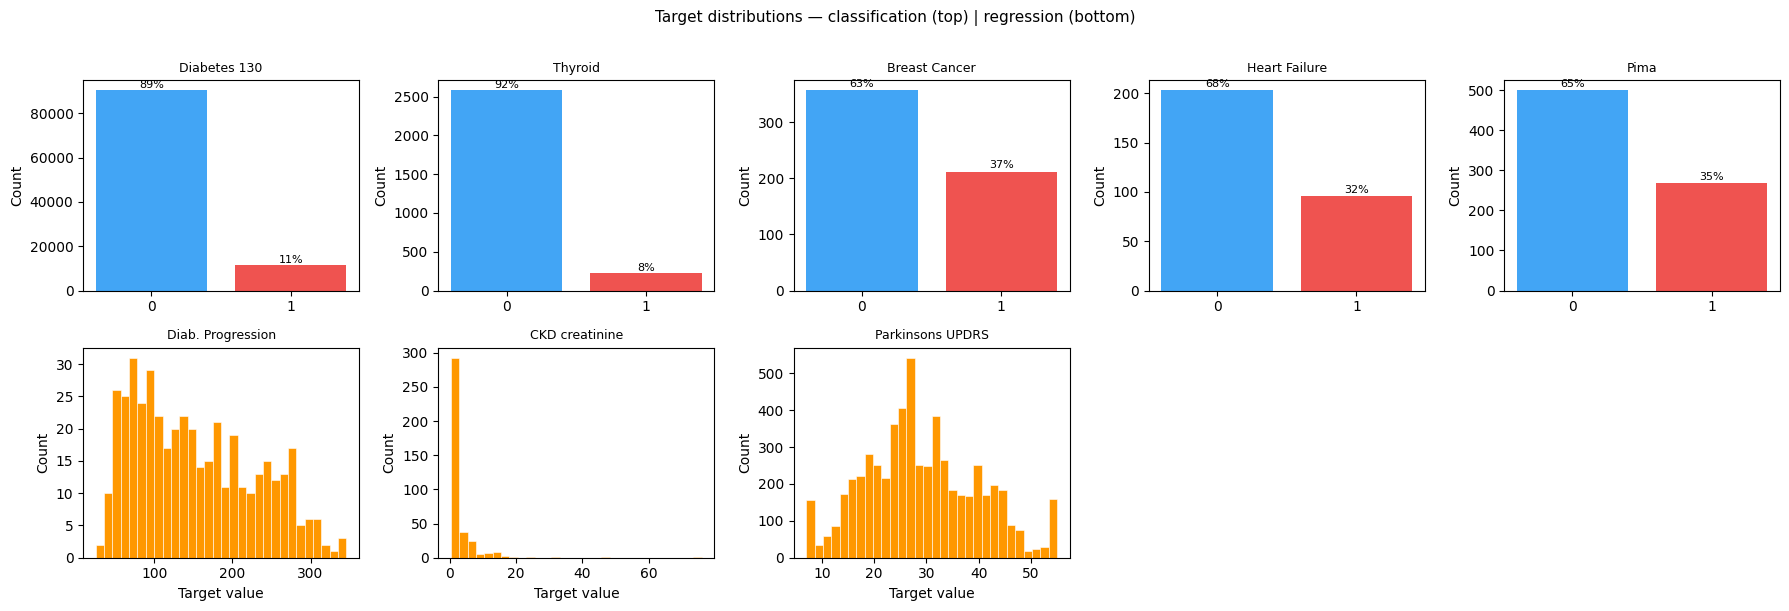

Done. Charts saved to medical_datasets_summary.png and medical_datasets_targets.png


In [13]:
# Target distributions
cls_pairs = [("Diabetes 130", y1), ("Thyroid", y2), ("Breast Cancer", y3),
             ("Heart Failure", y4), ("Pima", y5)]
reg_pairs = [("Diab. Progression", y6), ("CKD creatinine", y7), ("Parkinsons UPDRS", y8)]

fig, axes = plt.subplots(2, 5, figsize=(18, 6))

for ax, (name, y) in zip(axes[0], cls_pairs):
    vc = y.value_counts().sort_index()
    ax.bar([str(k) for k in vc.index], vc.values, color=['#42A5F5', '#EF5350'])
    ax.set_title(name, fontsize=9)
    ax.set_ylabel('Count')
    total = len(y)
    for i, (k, v) in enumerate(vc.items()):
        ax.text(i, v + total * 0.01, f'{v/total*100:.0f}%', ha='center', fontsize=8)

for ax, (name, y) in zip(axes[1][:3], reg_pairs):
    ax.hist(y.dropna(), bins=30, color='#FF9800', edgecolor='white', linewidth=0.4)
    ax.set_title(name, fontsize=9)
    ax.set_xlabel('Target value')
    ax.set_ylabel('Count')

for ax in axes[1][3:]:
    ax.set_visible(False)

plt.suptitle('Target distributions — classification (top) | regression (bottom)',
             fontsize=11, y=1.01)
plt.tight_layout()
plt.savefig('medical_datasets_targets.png', dpi=120, bbox_inches='tight')
plt.show()
print("Done. Charts saved to medical_datasets_summary.png and medical_datasets_targets.png")